<a href="https://colab.research.google.com/github/Lonebaithei/EDA_Assignment_2026/blob/main/T03_Exploratory_Data_Analysis_Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: Create the Tutorial 3 Notebook**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Step 2: Load Libraries and Interim Data**

In [2]:
orders = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/ADA2026_Instacart_Project/data/interim/orders_interim.csv")
products = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/ADA2026_Instacart_Project/data/interim/products_interim.csv")
order_products = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/ADA2026_Instacart_Project/data/interim/order_products__prior_interim.csv")

**Step 3: Confirm Table Meaning**

Inspect the tables using head() and confirm what each row represents. Identify key columns
for grouping and merging.

**Orders Table**

In [ ]:
# shows the key columns of the Orders table
orders.head()

### Interpretation of `orders` Table Columns

*   **`orders` DataFrame**:
    *   Each row represents a unique customer order.
    *   Key columns for grouping or merging:
        *   `order_id`: Unique identifier for each order, crucial for merging.
        *   `user_id`: Identifies the customer, essential for grouping orders by user behavior.
        *   `order_number`: Sequence of orders per user, useful for time-series analysis.
        *   `order_dow`: Day of the week (0-6) an order was placed, useful for daily pattern analysis.
        *   `order_hour_of_day`: Hour of the day (0-23) an order was placed, useful for hourly pattern analysis.
        *   `days_since_prior_order`: Number of days since the user's prior order, useful for analyzing order frequency.

In [3]:
# showing the COLUMN NAMES and DATA_TYPES
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 182.7+ MB


In [4]:
# showing the number RECORDS and COLUMNS
orders.shape

(3421083, 7)

**Products Table**

In [5]:
# shows the key columns and rows of the Orders table
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


### Interpretation of `products` Table

*   **`products` DataFrame**:
    *   Each row represents a unique product available for sale.
    *   Key columns for grouping or merging:
        *   `product_id`: Unique identifier for each product, crucial for merging with `order_products`.
        *   `product_name`: Descriptive name of the product.
        *   `aisle_id`: Categorical identifier for the product's aisle, useful for granular grouping.
        *   `department_id`: Categorical identifier for the product's department, useful for higher-level trend analysis and potential merging with a 'departments' DataFrame.


In [6]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49688 non-null  int64 
 1   product_name   49688 non-null  object
 2   aisle_id       49688 non-null  int64 
 3   department_id  49688 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [7]:
products.shape

(49688, 4)

**order_products Table**

In [8]:
# shows the key columns of the order_products table
order_products.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


### Interpretation of `order_products` Table

*   **`order_products` DataFrame**:
    *   Each row represents a specific product included in a particular order, linking orders and products.
    *   Key columns for grouping or merging:
        *   `order_id`: Foreign key linking to the `orders` DataFrame, essential for retrieving order details.
        *   `product_id`: Foreign key linking to the `products` DataFrame, essential for retrieving product details.
        *   `add_to_cart_order`: Sequence in which products were added to the cart, useful for analyzing user behavior during shopping.
        *   `reordered`: Binary flag (0 or 1) indicating if the product was a reorder, valuable for understanding customer loyalty.

In [9]:
# showing the COLUMN NAMES and DATA_TYPES
order_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 989.8 MB


In [10]:
# showing the number RECORDS and COLUMNS
order_products.shape

(32434489, 4)

**Step 4: Define Bivariate Questions**

These 3 questions guide the analysis, focusing on comparisons and
associations between variables.

1.  **What is the relationship between the day of the week (`order_dow`) and the number of products purchased in an order (`count of items per order)?**

This can help identify peak shopping days and how much customers tend to buy on those days.

2.  **How does the `reordered` status of a product relate to the `department_id` or `aisle_id`?**

This can reveal which product categories or specific aisles have higher customer loyalty and repeated visits to purchases.

3.  **Is there an relationship (association) between the `order_hour_of_day` and the `days_since_prior_order`?**

This could indicate if customers who order more frequently tend to shop at specific times, or if less frequent shoppers have different hourly patterns.

**Step 5: Categorical vs Categorical Analysis**

Create a contingency table:


In [ ]:
pd.crosstab(orders['order_dow'],orders['order_hour_of_day'])

order_hour_of_day,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
order_dow,,,,,,,,,,,,,,,,,,,,,
0,3936,2398,1409,963,813,1168,3329,12410,28108,40798,...,54552,53954,49463,39753,29572,22654,18277,14423,11246,6887
1,3674,1830,1105,748,809,1607,5370,16571,34116,51908,...,46764,46403,44761,36792,28977,22145,16281,11943,8992,5620
2,3059,1572,943,719,744,1399,4758,13245,24635,36314,...,37173,37469,37541,32151,26470,20084,15039,10653,8146,5358
3,2952,1495,953,654,719,1355,4562,12396,22553,32312,...,34773,35990,35273,30368,25001,19249,13795,10278,8242,5181
4,2642,1512,899,686,730,1330,4401,12493,21814,31409,...,33625,34222,34093,29378,24425,19350,14186,10796,8812,5645
5,3189,1672,1016,841,910,1574,4866,13434,24015,34232,...,37407,37508,35860,29955,24310,18741,13322,9515,7498,5265
6,3306,1919,1214,863,802,1136,3243,11319,22960,30839,...,38748,38093,35562,30398,24157,18346,13392,10501,8532,6087


### Interpretation of Dominant Days and Hours

By examining the contingency table we can identify patterns in customer ordering behavior:

*   **Overall Dominant Order Day:** `order_dow` 0 (is most likely Sunday, assuming 0 is Sunday) has the highest number of orders, with a peak of **54,552 orders** at `order_hour_of_day` 14 (2 PM).

*   **Peak Ordering Hours Across Days:**
    *   For `order_dow` 0 (Sunday), the peak is at **14:00 (2 PM)** with 54,552 orders.
    *   For `order_dow` 1 (Monday), the peak is at **9:00 (9 AM)** with 51,908 orders.
    *   Generally, the hours between **9:00 (9 AM)** and **16:00 (4 PM)** appear to be the busiest across most days of the week.

*   **Least Busy Hours:** Early morning hours (0:00 to 5:00) consistently show the lowest order volumes across all days, as expected.

This analysis suggests that **Sunday afternoons** and **Monday mornings** are particularly popular times for users to place their orders. This information can be valuable for operational planning, such as staffing customer service or optimizing delivery schedules.

**Step 6: Visualise Categorical Relationships**

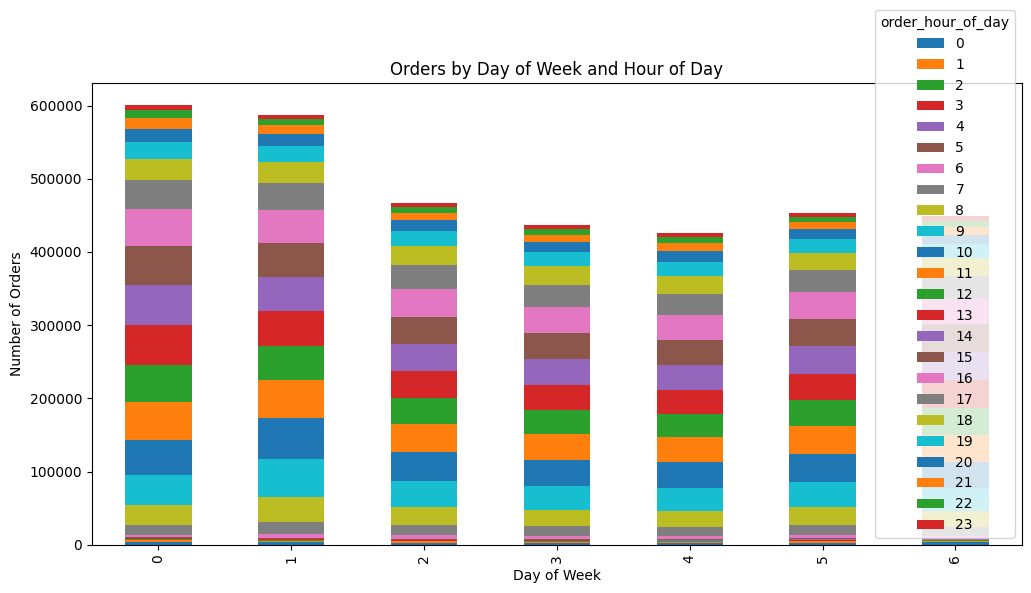

In [ ]:
ct = pd.crosstab(orders['order_dow'], orders['order_hour_of_day'])
ct.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.title("Orders by Day of Week and Hour of Day")
plt.show()

**Step 7: Numerical vs Categorical Analysis**

In [11]:
orders.groupby( 'order_dow') [ 'days_since_prior_order'].mean()

,days_since_prior_order
order_dow,
0,11.773868
1,11.311552
2,11.169766
3,10.768301
4,10.522935
5,10.508295
6,11.438924


In [12]:
orders.groupby ( 'order_dow') [ 'days_since_prior_order'].median()

,days_since_prior_order
order_dow,
0,8.0
1,8.0
2,8.0
3,7.0
4,7.0
5,7.0
6,7.0


**Step 8: Visual Comparison Using Boxplots**

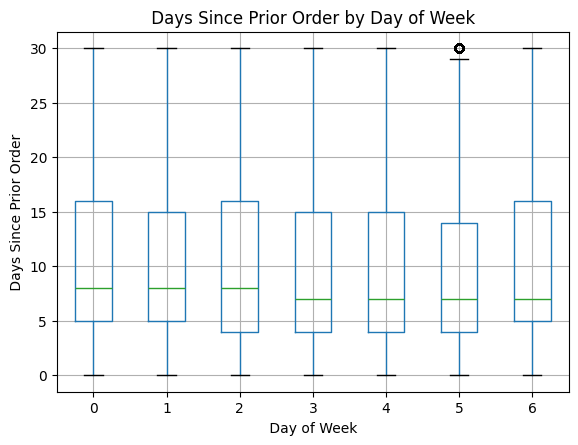

In [ ]:
orders . boxplot ( column = 'days_since_prior_order',by = 'order_dow')
plt.xlabel(" Day of Week ")
plt.ylabel(" Days Since Prior Order ")
plt.title(" Days Since Prior Order by Day of Week ")
plt.suptitle("")
plt.show()

**Step 9: Numerical vs Numerical Analysis**

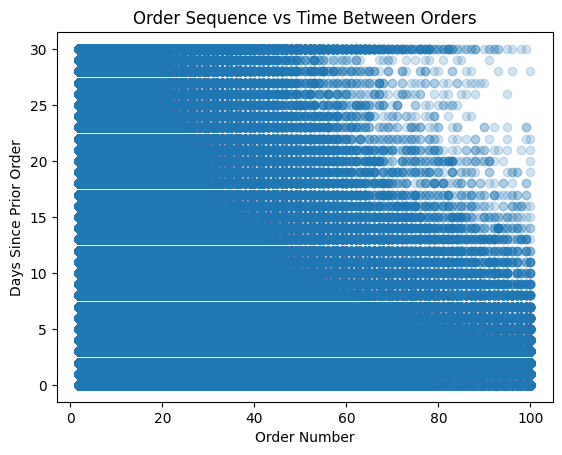

In [15]:
import matplotlib.pyplot as plt
tmp = orders [['order_number' , 'days_since_prior_order']].dropna()
plt.scatter(tmp['order_number'] , tmp['days_since_prior_order'] , alpha=0.2)
plt.xlabel ("Order Number")
plt.ylabel ("Days Since Prior Order")
plt.title ("Order Sequence vs Time Between Orders")
plt.show ()

**Step 10: Correlation**

In [16]:
tmp.corr()

,order_number,days_since_prior_order
order_number,1.000000,-0.360564
days_since_prior_order,-0.360564,1.000000


**Step 11: Reorder Behaviour Analysis**

In [17]:
merged = orders.merge(
    order_products[['order_id', 'reordered']],
    on='order_id',
    how='inner'
)
merged.groupby('order_dow')['reordered'].mean()

,reordered
order_dow,
0,0.585276
1,0.603843
2,0.589771
3,0.586272
4,0.590979
5,0.595470
6,0.574369
